# Punto 1 — Autoencoder para reconstrucción de imágenes

Nombre: **Lorena Anavia Coihuin**

Curso: *Deep Learning*

Profesor: *Reinel Tabares Soto*


En esta parte implementamos un Autoencoder denso sobre MNIST. Elegimos este dataset porque es el más simple de los sugeridos y nos permitió validar rápidamente la arquitectura; al trabajar con imágenes pequeñas y en escala de grises, pudimos concentrarnos en comprender el mecanismo encoder-decoder sin agregar complejidad innecesaria.

Optamos por un Autoencoder denso en lugar de uno convolucional porque, en esta etapa, nos interesa dejar clara la lógica de compresión y reconstrucción. El modelo convolucional puede capturar mejor la estructura espacial de las imágenes, pero también introduce más complejidad técnica; la versión densa nos permite explicar de manera más transparente cómo ocurre el aprendizaje interno.

El entrenamiento se configuró con MSE como función de pérdida y Adam como optimizador, priorizando estabilidad y rapidez de convergencia. Keras automatiza dentro de fit() el cálculo de gradientes, la retropropagación y la actualización de pesos, por lo que no es necesario programar ese proceso manualmente.

La dimensión del espacio latente no se obtiene con una fórmula fija; se define como hiperparámetro y se valida por experimentación. En este caso usamos 32 porque ofrece un equilibrio razonable entre compresión y calidad de reconstrucción para MNIST.

In [ ]:
# Verificar que la GPU está activa
import tensorflow as tf
print("GPU disponible:", tf.config.list_physical_devices('GPU'))
# Si retorna [] → ir a Entorno de ejecución → Cambiar tipo → GPU T4

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input, Flatten, Reshape
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error


## Preparación de MNIST para el Autoencoder

En esta celda cargamos el dataset MNIST, que contiene imágenes de dígitos escritos a mano. Luego normalizamos los píxeles para llevarlos de la escala 0–255 a 0.0–1.0, porque las redes neuronales aprenden mejor cuando los valores de entrada están acotados y bien escalados.

Después aplanamos cada imagen de 28x28 a un vector de 784 elementos. Esto es necesario porque el Autoencoder que estamos usando es denso, y las capas Dense requieren una entrada vectorial en lugar de una matriz bidimensional.


In [ ]:
# ============================================
# CELDA 2: DATOS
# ============================================

# Descarga automática de MNIST
(x_train, _), (x_test, _) = mnist.load_data()

# TIP 5: Normalizar ANTES de todo → valores de 0-255 pasan a 0.0-1.0 preparación para las capas Dense
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Aplanamos: de (28, 28) a (784,) para usar capas Dense
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

print("✅ Datos cargados y normalizados")
print("Forma entrenamiento:", x_train.shape)   # esperado: (60000, 784)
print("Forma test:         ", x_test.shape)    # esperado: (10000, 784)
print("Valor mínimo:", x_train.min(), "| Valor máximo:", x_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Datos cargados y normalizados
Forma entrenamiento: (60000, 784)
Forma test:          (10000, 784)
Valor mínimo: 0.0 | Valor máximo: 1.0


# Construcción del Autoencoder denso

Aquí definimos la arquitectura del Autoencoder. El encoder reduce la imagen de 784 valores a una representación comprimida de 32 dimensiones, también llamada espacio latente o cuello de botella. Esa compresión obliga al modelo a conservar solo la información más relevante de la imagen.

Luego, el decoder toma esa representación compacta y reconstruye la imagen original intentando recuperar la mayor cantidad posible de información. En términos simples, el encoder resume y el decoder reconstruye.

Para las capas ocultas del Autoencoder se optó por la función de activación ReLU debido a su eficiencia computacional y su capacidad para mitigar el desvanecimiento del gradiente durante el entrenamiento. Sin embargo, para la última capa del Decoder, se utilizó la función Sigmoide; esta decisión es crucial ya que asegura que los valores de los píxeles de la imagen reconstruida se mantengan estrictamente en el rango continuo de [0, 1], coincidiendo con la normalización aplicada al dataset original.



In [ ]:
# ============================================
# CELDA 3: ARQUITECTURA
# ============================================

LATENT_DIM = 32  # tamaño del espacio latente (cuello de botella)  compresión razonable para MNIST

# -- ENCODER: comprime 784 → 32 --
input_img = Input(shape=(784,))
encoded   = Dense(128, activation='relu')(input_img)
encoded   = Dense(64,  activation='relu')(encoded)
latente   = Dense(LATENT_DIM, activation='relu')(encoded)

# -- DECODER: expande 32 → 784 --
decoded   = Dense(64,  activation='relu')(latente)
decoded   = Dense(128, activation='relu')(decoded)
output_img = Dense(784, activation='sigmoid')(decoded)

# -- MODELO COMPLETO --
autoencoder = Model(input_img, output_img)

# TIP 6: Verificar arquitectura antes de entrenar
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

La salida de summary() te permite verificar tres cosas:


1.   que la arquitectura quedó simétrica,
1.   que el espacio latente realmente tiene 32 neuronas,
1.   que el número total de parámetros es coherente con el tamaño de la red.



### Nota importante sobre 32

La dimensión latente no se obtiene con una fórmula única; se elige como hiperparámetro y se valida por experimentación. En este caso usamos 32 porque ofrece un equilibrio práctico entre compresión y calidad de reconstrucción para MNIST

### ¿Qué ocurre en el Espacio Latente?  
Matemáticamente, el espacio latente de 32 dimensiones actúa como un cuello de botella (bottleneck). Si utilizáramos un espacio latente demasiado grande, la red simplemente "memorizaría" la entrada. Al forzar una dimensión de 32 para representar 784 píxeles, obligamos al modelo a realizar una extracción de características (feature extraction).

## Configuración del aprendizaje del Autoencoder
En esta celda configuramos el aprendizaje del modelo. Usamos MSE porque queremos medir qué tan distinta queda la imagen reconstruida respecto de la original. Adam se eligió como optimizador por su buena estabilidad y su rápida convergencia en problemas como MNIST.

Cuando llamamos a fit(), Keras ejecuta el proceso completo de entrenamiento: propagación hacia adelante, cálculo de la pérdida, retropropagación, obtención de gradientes y actualización de pesos en cada batch.




In [ ]:
# ============================================
# CELDA 4 V1: ENTRENAMIENTO Función de pérdida MSE
# Empezamos con 5 épocas para verificar
# que no hay bugs antes de entrenar completo
# ============================================

autoencoder.compile(optimizer=Adam(learning_rate=0.001),
                    loss='mse')

history = autoencoder.fit(
    x_train, x_train,        # input = output → el modelo aprende a copiarse
    epochs=5,                # ← primero 5 para probar
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

# TIP 4: Guardar INMEDIATAMENTE después del fit()
autoencoder.save('/content/autoencoder.keras')
print("✅ Modelo guardado en Drive")

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0653 - val_loss: 0.0370
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0306 - val_loss: 0.0256
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0238 - val_loss: 0.0213
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0206 - val_loss: 0.0191
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0189 - val_loss: 0.0178
✅ Modelo guardado en Drive


Cuando llamamos a fit(), Keras ejecuta el proceso completo de entrenamiento: propagación hacia adelante, cálculo de la pérdida, retropropagación, obtención de gradientes y actualización de pesos en cada batch.

In [ ]:
# ============================================
# CELDA 4 V2: ENTRENAMIENTO
# 20 épocas
# ============================================

history = autoencoder.fit(
    x_train, x_train,
    epochs=20,           # ← cambia de 5 a 20
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)
autoencoder.save('/content/autoencoder_final.keras')

print("✅ Modelo final guardado")

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0174 - val_loss: 0.0163
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0162 - val_loss: 0.0154
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0154 - val_loss: 0.0146
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0146 - val_loss: 0.0138
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0139 - val_loss: 0.0133
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0134 - val_loss: 0.0132
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0130 - val_loss: 0.0124
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0126 - val_loss: 0.0121
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0122 - val_loss: 0.0116
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0118 - val_loss: 0.0113
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0115 - val_loss: 0.0111
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

También se podría usar SGD con momentum como alternativa más clásica, pero para este taller Adam resulta más práctico porque acelera la convergencia y reduce el riesgo de necesitar demasiado ajuste manual.

## Curva de pérdida Seguimiento del aprendizaje del Autoencoder

Esta gráfica nos permite revisar cómo evolucionó el entrenamiento del modelo. La curva de entrenamiento muestra el error sobre los datos usados para aprender, mientras que la curva de validación muestra el comportamiento sobre datos no vistos durante el ajuste. Si ambas bajan de forma similar, el aprendizaje es estable y no hay señales fuertes de sobreajuste.

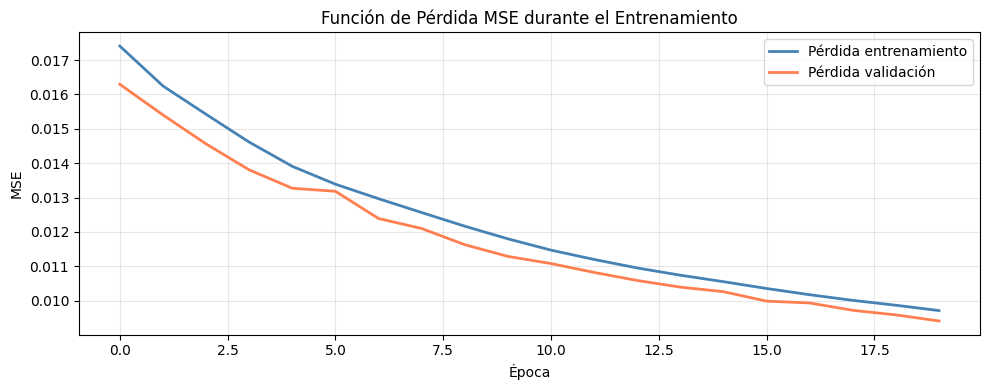

✅ Gráfica guardada en Drive


In [ ]:
# ============================================
# CELDA 5: GRÁFICA DE PÉRDIDA
# ============================================

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Pérdida entrenamiento', color='steelblue',  linewidth=2)
plt.plot(history.history['val_loss'], label='Pérdida validación',    color='coral', linewidth=2)
plt.title('Función de Pérdida MSE durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/perdida_autoencoder.png')

plt.show()
print("✅ Gráfica guardada en Drive")

Además de revisar la pérdida, comparamos imágenes originales con reconstrucciones. Esta verificación visual es importante porque una pérdida baja no siempre garantiza que la reconstrucción se vea bien; por eso contrastamos ambas filas de imágenes para confirmar que el Autoencoder conservó la estructura esencial de los dígitos.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step


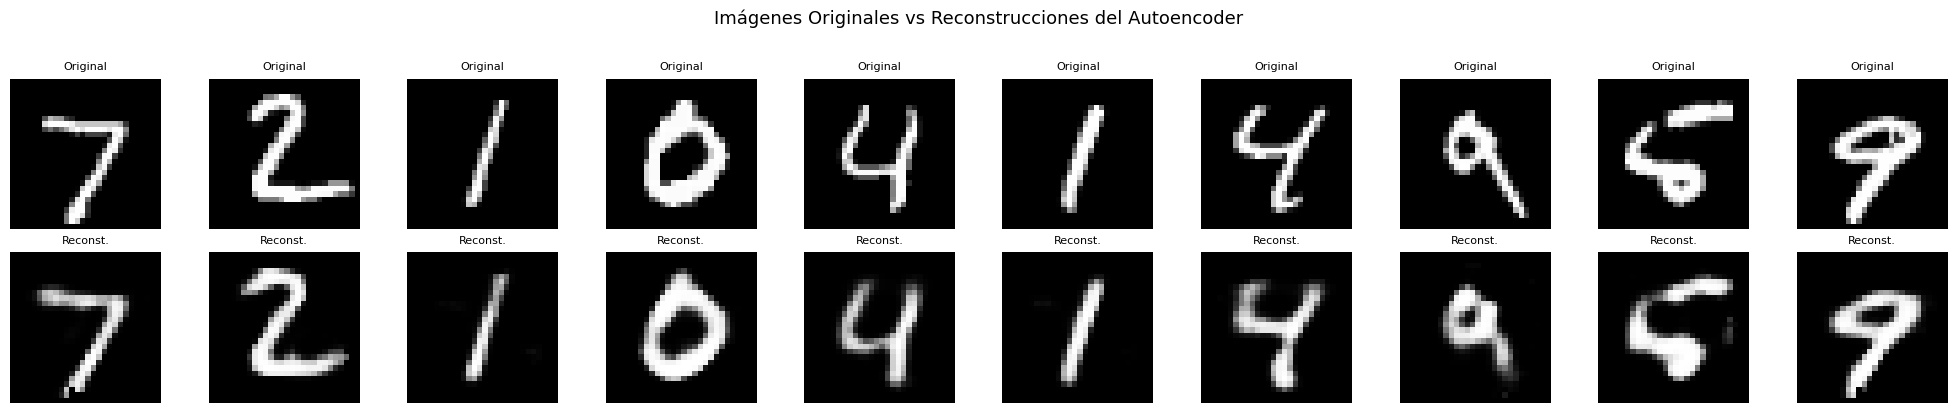

✅ Comparación guardada en Drive


In [ ]:
# ============================================
# CELDA 6: ORIGINALES vs RECONSTRUCCIONES
# ============================================

reconstruidas = autoencoder.predict(x_test[:10])

fig, axes = plt.subplots(2, 10, figsize=(20, 4))

for i in range(10):
    # Fila 1: imágenes originales
    axes[0, i].imshow(x_test[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f'Original', fontsize=8)
    axes[0, i].axis('off')

    # Fila 2: imágenes reconstruidas
    axes[1, i].imshow(reconstruidas[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f'Reconst.', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('Imágenes Originales vs Reconstrucciones del Autoencoder', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/content/comparacion_autoencoder.png', bbox_inches='tight')
plt.show()
print("✅ Comparación guardada en Drive")

La implementación del Autoencoder se realizó con una arquitectura encoder-decoder sobre MNIST, elegido por su simplicidad y utilidad para validar rápidamente el modelo. El entrenamiento se configuró con MSE como función de pérdida y Adam como optimizador, mientras que Keras automatiza el cálculo de gradientes, la retropropagación y la actualización de pesos durante fit().